In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

RANDOM_STATE = 42
TARGET_COL = "Energy_Consumption_kWh"
_cwd = os.getcwd()
ROOT = os.path.dirname(_cwd) if os.path.basename(_cwd) == "notebooks" else _cwd
OUTPUT_DIR = ROOT
FEATURE_MAP_PATH = os.path.join(OUTPUT_DIR, "feature_map.md")

## Dataset Loading

The raw EV Energy Consumption dataset is loaded directly from `energy-model/data/raw/EV_Energy_Consumption_Dataset.csv`.

In [2]:
csv_path = os.path.join(ROOT, "data", "raw", "EV_Energy_Consumption_Dataset.csv")
df = pd.read_csv(csv_path)

print(f"Path: {csv_path}")
print(f"Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

df.head(5).T

Path: /home/yunus_emre/main/GNN-Based-Electric-Vehicle-Route-Optimizer/energy-model/data/raw/EV_Energy_Consumption_Dataset.csv
Shape: (5000, 19)
Memory Usage: 0.82 MB


,0,1,2,3,4
Vehicle_ID,1102,1435,1860,1270,1106
Timestamp,2024-01-01 00:00:00,2024-01-01 00:01:00,2024-01-01 00:02:00,2024-01-01 00:03:00,2024-01-01 00:04:00
Speed_kmh,111.507,48.612,108.733,38.579,57.172
Acceleration_ms2,-2.774,-0.797,0.254,-2.111,1.478
Battery_State_%,30.415,97.386,84.913,28.778,29.740
Battery_Voltage_V,378.092,392.718,398.993,358.128,310.888
Battery_Temperature_C,25.315,18.241,44.449,28.980,33.185
Driving_Mode,2,1,1,1,2
Road_Type,1,2,1,2,1
Traffic_Condition,1,1,3,2,1


## Structural Overview

Column types, missing values, and descriptive statistics.

In [3]:
print("─" * 55)
print("COLUMN TYPES")
print("─" * 55)
print(df.dtypes.value_counts())

print("\n" + "─" * 55)
print("MISSING VALUES")
print("─" * 55)
missing = df.isnull().sum()
missing = missing[missing > 0]
if missing.empty:
    print("No missing values detected.")
else:
    print(missing)

print("\n" + "─" * 55)
print("DESCRIPTIVE STATISTICS")
print("─" * 55)
df.describe().T.style.background_gradient(cmap="Blues", subset=["mean", "std", "50%"])

───────────────────────────────────────────────────────
COLUMN TYPES
───────────────────────────────────────────────────────
float64    13
int64       5
str         1
Name: count, dtype: int64

───────────────────────────────────────────────────────
MISSING VALUES
───────────────────────────────────────────────────────
No missing values detected.

───────────────────────────────────────────────────────
DESCRIPTIVE STATISTICS
───────────────────────────────────────────────────────


,count,mean,std,min,25%,50%,75%,max
Vehicle_ID,5000.000000,1505.701200,290.836902,1000.000000,1253.000000,1510.000000,1761.000000,1999.000000
Speed_kmh,5000.000000,59.312952,34.517605,0.001396,29.515400,58.646794,89.030001,119.946924
Acceleration_ms2,5000.000000,-0.019885,1.724287,-2.999683,-1.490240,-0.043329,1.473887,2.998039
Battery_State_%,5000.000000,60.214465,23.128262,20.020196,40.088318,60.490283,80.409928,99.993986
Battery_Voltage_V,5000.000000,351.118306,28.968372,300.004812,326.613439,351.510915,375.968140,399.990098
Battery_Temperature_C,5000.000000,27.510130,10.015385,10.003858,18.884742,27.581710,35.920162,44.985943
Driving_Mode,5000.000000,2.011000,0.810068,1.000000,1.000000,2.000000,3.000000,3.000000
Road_Type,5000.000000,1.999200,0.808536,1.000000,1.000000,2.000000,3.000000,3.000000
Traffic_Condition,5000.000000,2.010800,0.812167,1.000000,1.000000,2.000000,3.000000,3.000000
Slope_%,5000.000000,2.504690,4.360854,-4.991079,-1.235653,2.452368,6.366990,9.998358


## Target Variable Analysis

Distribution of `Energy_Consumption_kWh` is examined. Skewness is near zero
(0.02), so no log transformation is needed — this is confirmed at runtime.

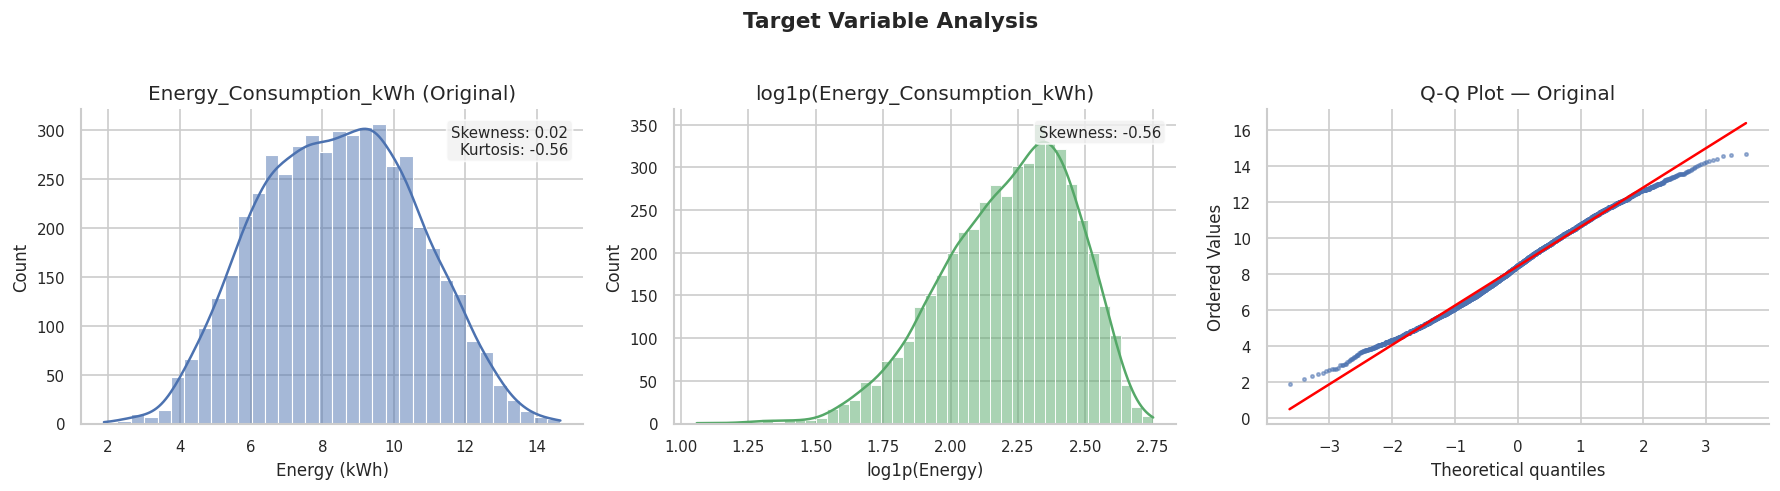

Original skewness: 0.0206
log1p skewness: -0.5588
Decision: apply_log1p = False


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
sns.histplot(df[TARGET_COL], kde=True, ax=ax, color="#4C72B0", edgecolor="white")
ax.set_title(f"{TARGET_COL} (Original)")
ax.set_xlabel("Energy (kWh)")
skew_orig = df[TARGET_COL].skew()
kurt_orig = df[TARGET_COL].kurtosis()
ax.text(0.97, 0.95, f"Skewness: {skew_orig:.2f}\nKurtosis: {kurt_orig:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", alpha=0.8))

ax = axes[1]
log_target = np.log1p(df[TARGET_COL])
sns.histplot(log_target, kde=True, ax=ax, color="#55A868", edgecolor="white")
ax.set_title("log1p(Energy_Consumption_kWh)")
ax.set_xlabel("log1p(Energy)")
skew_log = log_target.skew()
ax.text(0.97, 0.95, f"Skewness: {skew_log:.2f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#f0f0f0", alpha=0.8))

ax = axes[2]
stats.probplot(df[TARGET_COL], dist="norm", plot=ax)
ax.set_title("Q-Q Plot — Original")
ax.get_lines()[0].set(markersize=2, alpha=0.5, color="#4C72B0")
ax.get_lines()[1].set(color="red", linewidth=1.5)

plt.suptitle("Target Variable Analysis", fontsize=13, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Original skewness: {skew_orig:.4f}")
print(f"log1p skewness: {skew_log:.4f}")
print(f"Decision: apply_log1p = {abs(skew_log) < abs(skew_orig)}")

## Feature Correlations with Target

`Speed_kmh` dominates with |r|=0.793, confirming aerodynamic drag (∝ v²)
as the primary energy driver. `Humidity_%` (0.173) and `Battery_Temperature_C`
(0.141) are informative but excluded from the model because they are not
available in the inference pipeline.

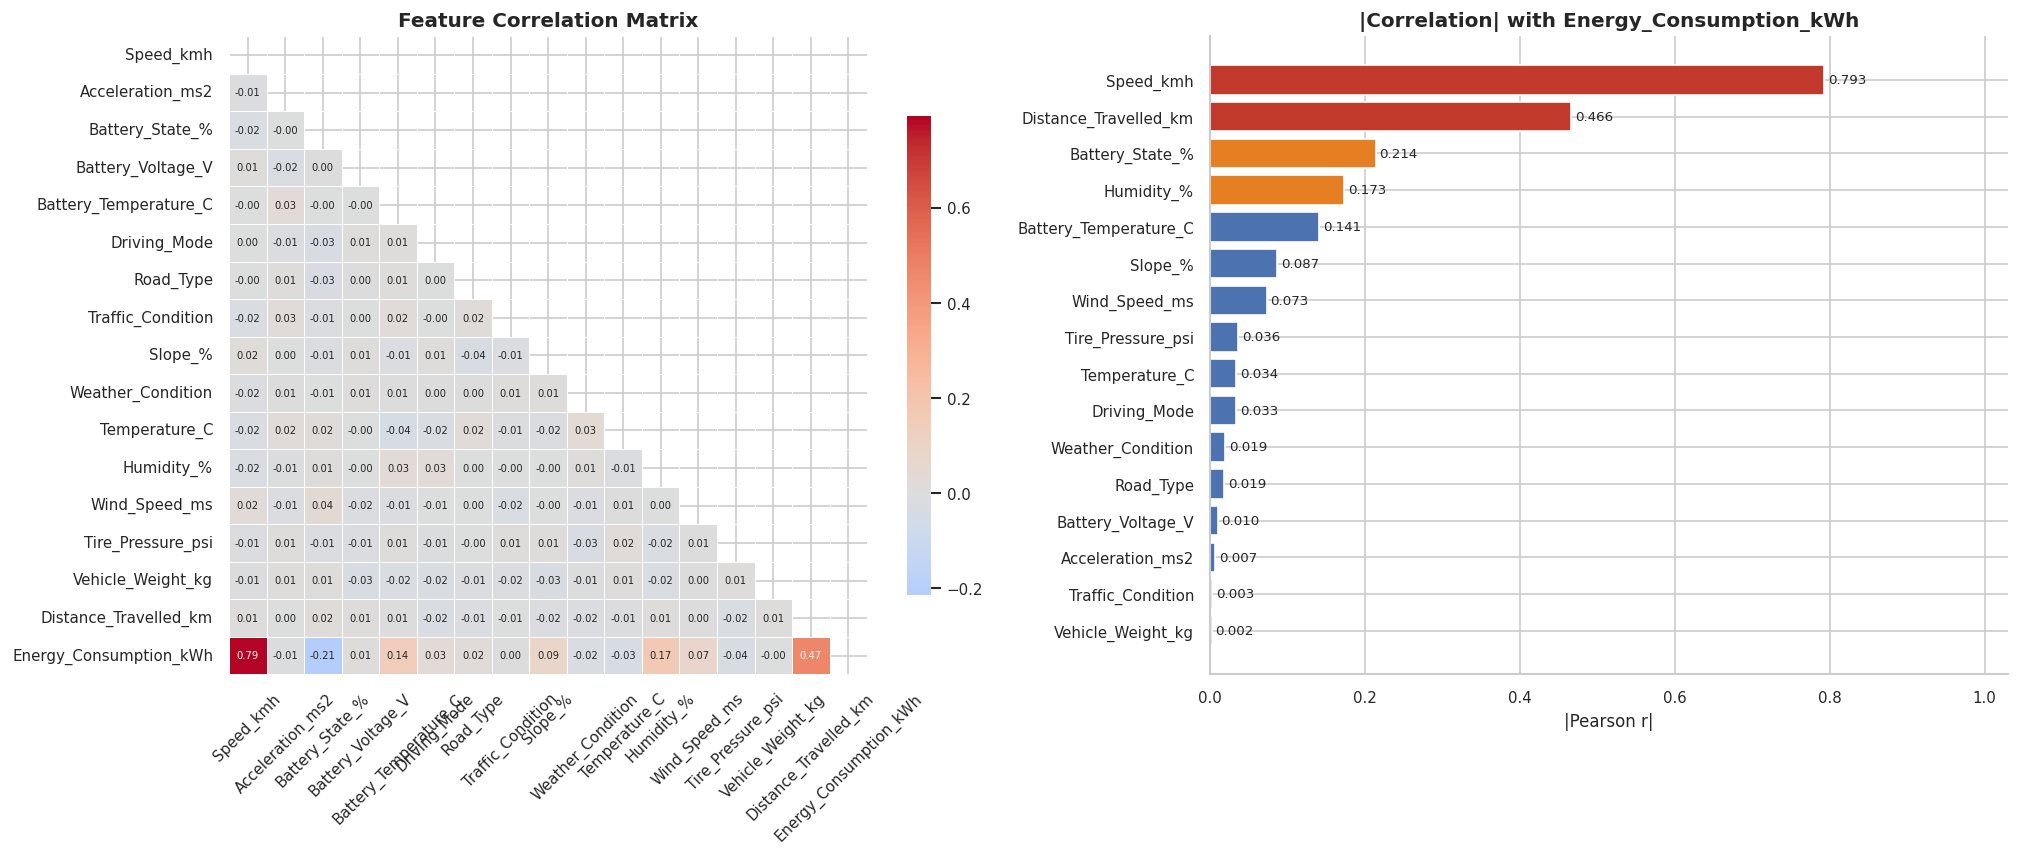

Top-5 features:
Speed_kmh               0.793
Distance_Travelled_km   0.466
Battery_State_%         0.214
Humidity_%              0.173
Battery_Temperature_C   0.141

NOTE: Humidity_% and Battery_Temperature_C are informative but NOT
available at inference -- excluded from model and graph topology.


In [5]:
IDENTIFIER_COLS = ["Vehicle_ID", "Timestamp"]
num_df = df.drop(columns=IDENTIFIER_COLS).select_dtypes(include=[np.number])

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

ax = axes[0]
corr_matrix = num_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, ax=ax,
    cmap="coolwarm", center=0,
    annot=True, fmt=".2f", annot_kws={"size": 6},
    linewidths=0.4, square=True,
    cbar_kws={"shrink": 0.75},
)
ax.set_title("Feature Correlation Matrix", fontweight="bold")
ax.tick_params(axis="x", rotation=45)

ax = axes[1]
target_corr = (
    num_df.corr()[TARGET_COL]
    .drop(TARGET_COL)
    .abs()
    .sort_values(ascending=True)
)
colors = [
    "#c0392b" if v > 0.4 else "#e67e22" if v > 0.15 else "#4C72B0"
    for v in target_corr
]
bars = ax.barh(target_corr.index, target_corr.values, color=colors, edgecolor="white")
ax.set_title(f"|Correlation| with {TARGET_COL}", fontweight="bold")
ax.set_xlabel("|Pearson r|")
ax.set_xlim(0, target_corr.max() * 1.3)
for bar, val in zip(bars, target_corr.values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=8)

plt.tight_layout()
plt.show()

print("Top-5 features:")
print(target_corr.sort_values(ascending=False).head(5).to_string())
print("\nNOTE: Humidity_% and Battery_Temperature_C are informative but NOT")
print("available at inference -- excluded from model and graph topology.")

## Categorical Features — Relationship with Target

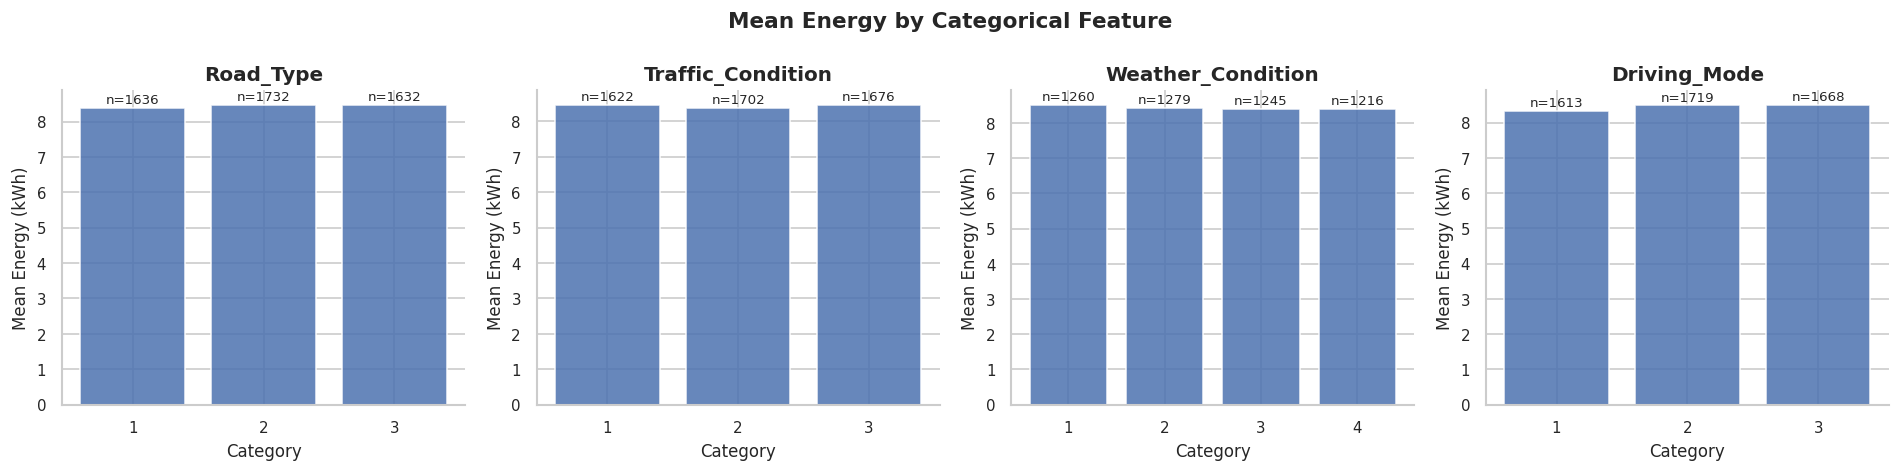

In [6]:
CATEGORICAL_COLS = ["Road_Type", "Traffic_Condition", "Weather_Condition", "Driving_Mode"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, CATEGORICAL_COLS):
    means = df.groupby(col)[TARGET_COL].mean().sort_index()
    counts = df[col].value_counts().sort_index()
    bars = ax.bar(means.index.astype(str), means.values,
                  color="#4C72B0", edgecolor="white", alpha=0.85)
    ax.set_title(col, fontweight="bold")
    ax.set_xlabel("Category")
    ax.set_ylabel("Mean Energy (kWh)")
    for bar, (cat, cnt) in zip(bars, counts.items()):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                f"n={cnt}", ha="center", va="bottom", fontsize=8)

plt.suptitle("Mean Energy by Categorical Feature", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Feature Engineering Candidates

Five physics-motivated features are derived from the inference-available base set.
`speed_x_length` (energy = force × distance ≈ drag × distance ∝ v × d) is the
strongest predictor at |r|=0.822, surpassing `Speed_kmh` alone.

`speed_sq` and `wind_speed_sq` are **excluded** despite physical motivation
(aerodynamic drag ∝ v²): both are near-collinear with their base features
(`speed_kmh`/`speed_sq` |r|=0.976, VIF≈25; `wind_speed`/`wind_speed_sq`
|r|=0.968, VIF≈16). Including them does not improve predictive performance
but inflates inter-feature correlation and destabilises gradient attribution
across the two collinear columns. The remaining five engineered features are
retained as they capture physically distinct signal not already encoded
by any single base feature.

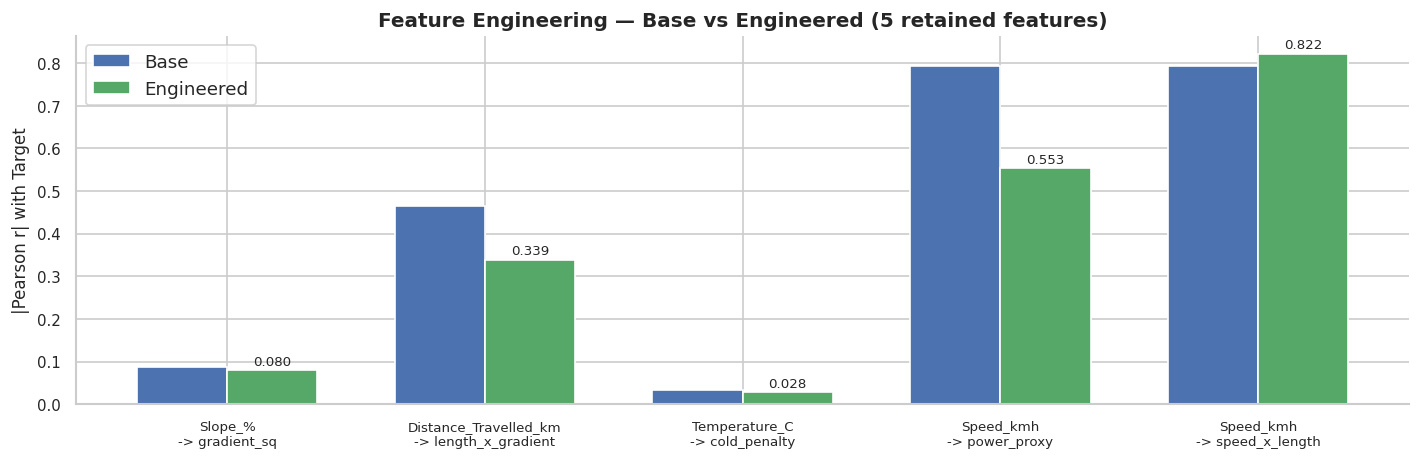

       Engineered          Base Feature  Base |r|  Engineered |r|  Delta
      gradient_sq               Slope_%     0.087           0.080 -0.007
length_x_gradient Distance_Travelled_km     0.466           0.339 -0.127
     cold_penalty         Temperature_C     0.034           0.028 -0.006
      power_proxy             Speed_kmh     0.793           0.553 -0.240
   speed_x_length             Speed_kmh     0.793           0.822  0.029

Dropped (collinearity): speed_sq (VIF≈25), wind_speed_sq (VIF≈16)


In [7]:
INFERENCE_AVAILABLE = [
    "Distance_Travelled_km", "Slope_%", "Road_Type", "Traffic_Condition",
    "Temperature_C", "Wind_Speed_ms", "Weather_Condition",
    "Speed_kmh", "Battery_State_%", "Acceleration_ms2",
]

fe_df = df[INFERENCE_AVAILABLE + [TARGET_COL]].copy()
fe_df["gradient_sq"]       = fe_df["Slope_%"] ** 2
fe_df["length_x_gradient"] = fe_df["Distance_Travelled_km"] * fe_df["Slope_%"].abs()
fe_df["cold_penalty"]      = np.maximum(0.0, -fe_df["Temperature_C"])
fe_df["power_proxy"]       = fe_df["Speed_kmh"] / 3.6 * fe_df["Acceleration_ms2"].abs()
fe_df["speed_x_length"]    = fe_df["Speed_kmh"] * fe_df["Distance_Travelled_km"]
# speed_sq  (|r|=0.976 with speed_kmh, VIF≈25) — dropped: collinear with speed_kmh
# wind_speed_sq (|r|=0.968 with wind_speed, VIF≈16) — dropped: collinear with wind_speed

BASE_MAP = {
    "gradient_sq":       "Slope_%",
    "length_x_gradient": "Distance_Travelled_km",
    "cold_penalty":      "Temperature_C",
    "power_proxy":       "Speed_kmh",
    "speed_x_length":    "Speed_kmh",
}
ENGINEERED_COLS = list(BASE_MAP.keys())

rows = []
for eng_col, base_col in BASE_MAP.items():
    base_r = abs(fe_df[base_col].corr(fe_df[TARGET_COL]))
    eng_r  = abs(fe_df[eng_col].corr(fe_df[TARGET_COL]))
    rows.append({
        "Engineered":      eng_col,
        "Base Feature":    base_col,
        "Base |r|":        round(base_r, 4),
        "Engineered |r|":  round(eng_r, 4),
        "Delta":           round(eng_r - base_r, 4),
    })

cmp = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(cmp))
width = 0.35
bars1 = ax.bar(x - width / 2, cmp["Base |r|"],
               width, label="Base", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width / 2, cmp["Engineered |r|"],
               width, label="Engineered", color="#55A868", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(
    [f"{r['Base Feature']}\n-> {r['Engineered']}" for _, r in cmp.iterrows()],
    fontsize=8,
)
ax.set_ylabel("|Pearson r| with Target")
ax.set_title("Feature Engineering — Base vs Engineered (5 retained features)", fontweight="bold")
ax.legend()
for b, val in zip(bars2, cmp["Engineered |r|"]):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.005,
            f"{val:.3f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

print(cmp.to_string(index=False))
print("\nDropped (collinearity): speed_sq (VIF≈25), wind_speed_sq (VIF≈16)")

## Outlier Analysis

IQR-based outlier rates are computed for each numerical feature.

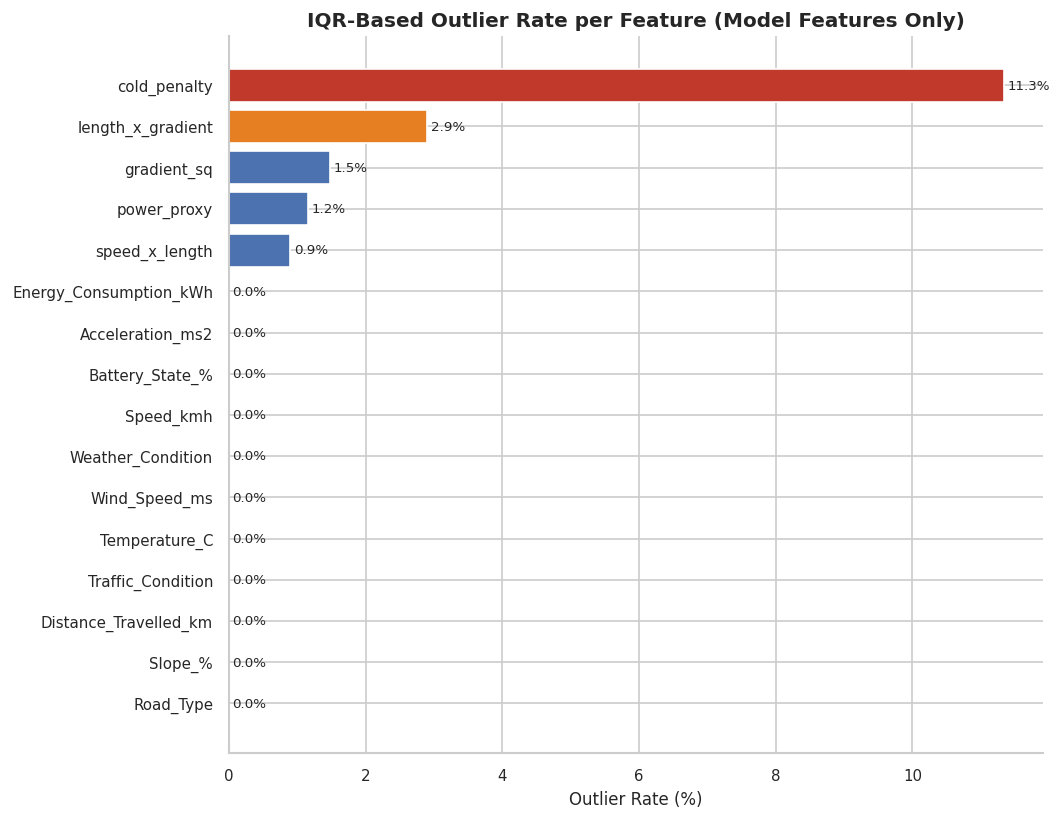

                        Outlier Count  Outlier Rate%
Feature                                             
cold_penalty                      567         11.340
length_x_gradient                 145          2.900
gradient_sq                        74          1.480
power_proxy                        58          1.160
speed_x_length                     45          0.900
Distance_Travelled_km               0          0.000
Road_Type                           0          0.000
Slope_%                             0          0.000
Speed_kmh                           0          0.000
Weather_Condition                   0          0.000
Wind_Speed_ms                       0          0.000
Temperature_C                       0          0.000
Traffic_Condition                   0          0.000
Acceleration_ms2                    0          0.000
Battery_State_%                     0          0.000
Energy_Consumption_kWh              0          0.000


In [8]:
MODEL_COLS = INFERENCE_AVAILABLE + ENGINEERED_COLS

def iqr_outlier_summary(frame, columns):
    records = []
    for col in columns:
        q1, q3 = frame[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((frame[col] < lower) | (frame[col] > upper)).sum()
        records.append({
            "Feature": col,
            "Lower Fence": round(lower, 3),
            "Upper Fence": round(upper, 3),
            "Outlier Count": int(n_out),
            "Outlier Rate%": round(n_out / len(frame) * 100, 2),
        })
    return pd.DataFrame(records).set_index("Feature").sort_values("Outlier Rate%", ascending=False)

outlier_df = iqr_outlier_summary(fe_df, MODEL_COLS + [TARGET_COL])

fig, ax = plt.subplots(figsize=(9, 7))
rates = outlier_df["Outlier Rate%"].sort_values(ascending=True)
colors = ["#c0392b" if v > 5 else "#e67e22" if v > 2 else "#4C72B0" for v in rates]
bars = ax.barh(rates.index, rates.values, color=colors, edgecolor="white")
ax.set_title("IQR-Based Outlier Rate per Feature (Model Features Only)", fontweight="bold")
ax.set_xlabel("Outlier Rate (%)")
for bar, val in zip(bars, rates.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

print(outlier_df[["Outlier Count", "Outlier Rate%"]].to_string())

## Feature Map Export

Decisions are written to `energy-model/artifacts/feature_map.md`. This file documents feature choices, correlations, and exclusion rationale for reference during model development.

In [9]:
apply_log1p_flag = bool(abs(skew_log) < abs(skew_orig))

FEATURE_MAP_CONTENT = f"""# Feature Map — EV Energy GCN

Generated by: EV Energy – EDA & Feature Analysis
Target: `{TARGET_COL}`
Graph node: one road segment traversal record
Graph edges: k-NN on KNN_GRAPH_COLS = {["speed_kmh", "length", "gradient"]}

---

## Node Features — Base (inference-available)

| Feature (production) | Dataset Column | |r| target | Inference Source |
|---|---|---|---|
| length | Distance_Travelled_km | {abs(fe_df["Distance_Travelled_km"].corr(fe_df[TARGET_COL])):.3f} | static — OSMnx edge |
| gradient | Slope_% | {abs(fe_df["Slope_%"].corr(fe_df[TARGET_COL])):.3f} | static — OSMnx edge |
| surface_type | Road_Type | {abs(fe_df["Road_Type"].corr(fe_df[TARGET_COL])):.3f} | static — OSMnx edge |
| traffic_density | Traffic_Condition | {abs(fe_df["Traffic_Condition"].corr(fe_df[TARGET_COL])):.3f} | dynamic — MockDynamicService |
| temperature | Temperature_C | {abs(fe_df["Temperature_C"].corr(fe_df[TARGET_COL])):.3f} | dynamic — MockDynamicService |
| wind_speed | Wind_Speed_ms | {abs(fe_df["Wind_Speed_ms"].corr(fe_df[TARGET_COL])):.3f} | dynamic — MockDynamicService |
| weather_condition | Weather_Condition | {abs(fe_df["Weather_Condition"].corr(fe_df[TARGET_COL])):.3f} | dynamic — MockDynamicService |
| speed_kmh | Speed_kmh | {abs(fe_df["Speed_kmh"].corr(fe_df[TARGET_COL])):.3f} | road — speed_limit from OSMnx |
| battery_soc | Battery_State_% | {abs(fe_df["Battery_State_%"].corr(fe_df[TARGET_COL])):.3f} | vehicle — routing request |
| acceleration | Acceleration_ms2 | {abs(fe_df["Acceleration_ms2"].corr(fe_df[TARGET_COL])):.3f} | vehicle — default per road type |

## Node Features — Engineered

| Feature | Derivation | |r| target | Rationale |
|---|---|---|---|
| gradient_sq | gradient ** 2 | {abs(fe_df["gradient_sq"].corr(fe_df[TARGET_COL])):.3f} | Non-linear grade resistance |
| length_x_gradient | length x abs(gradient) | {abs(fe_df["length_x_gradient"].corr(fe_df[TARGET_COL])):.3f} | Total elevation work proxy |
| cold_penalty | max(0, -temperature) | {abs(fe_df["cold_penalty"].corr(fe_df[TARGET_COL])):.3f} | Sub-zero battery efficiency loss |
| power_proxy | speed_kmh/3.6 x abs(acceleration) | {abs(fe_df["power_proxy"].corr(fe_df[TARGET_COL])):.3f} | Instantaneous power demand proxy |
| speed_x_length | speed_kmh x length | {abs(fe_df["speed_x_length"].corr(fe_df[TARGET_COL])):.3f} | Best single engineered predictor |

Total node feature dim: {len(INFERENCE_AVAILABLE) + len(ENGINEERED_COLS)}

---

## k-NN Graph Topology

KNN_GRAPH_COLS = ['speed_kmh', 'length', 'gradient']

Nodes connected in this space share genuine energy context — similar speed
regime, comparable distance, similar grade. GCNConv aggregating over these
neighbours provides real regularisation signal that a plain MLP cannot use.

Humidity_% (|r|=0.173) and
Battery_Temperature_C (|r|=0.141)
are informative but excluded — not available in the inference pipeline.

---

## Excluded Features

| Feature | Reason |
|---|---|
| Humidity_% | |r|=0.173, NOT available at inference |
| Battery_Temperature_C | |r|=0.141, NOT available at inference |
| Battery_Voltage_V | Redundant with battery_soc |
| Vehicle_Weight_kg | |r|=0.002, no predictive value |
| Driving_Mode | Not in inference pipeline |
| Tire_Pressure_psi | Not in inference pipeline |
| Vehicle_ID | Identifier |
| Timestamp | Identifier |

apply_log1p: {apply_log1p_flag}
"""

os.makedirs(OUTPUT_DIR, exist_ok=True)
with open(FEATURE_MAP_PATH, "w", encoding="utf-8") as f:
    f.write(FEATURE_MAP_CONTENT)

print(f"Feature map written to: {FEATURE_MAP_PATH}")


# | wind_speed_sq | wind_speed ** 2 | {abs(fe_df["wind_speed_sq"].corr(fe_df[TARGET_COL])):.3f} | Aerodynamic drag proportional to v^2 |
# | speed_sq | speed_kmh ** 2 | {abs(fe_df["speed_sq"].corr(fe_df[TARGET_COL])):.3f} | Aerodynamic drag dominant term |

Feature map written to: /home/yunus_emre/main/GNN-Based-Electric-Vehicle-Route-Optimizer/energy-model/feature_map.md


## Summary

In [10]:
findings = {
    "dataset_shape":      df.shape,
    "missing_values":     int(df.isnull().sum().sum()),
    "target_skewness":    round(skew_orig, 4),
    "apply_log1p":        abs(skew_log) < abs(skew_orig),
    "base_features":      INFERENCE_AVAILABLE,
    "engineered_features": ENGINEERED_COLS,
    "dropped_collinear":  ["speed_sq (VIF≈25)", "wind_speed_sq (VIF≈16)"],
    "total_feature_dim":  len(INFERENCE_AVAILABLE) + len(ENGINEERED_COLS),
    "knn_graph_features": ["speed_kmh", "length", "gradient"],
    "excluded_informative": ["Humidity_%  (|r|=0.173)", "Battery_Temperature_C (|r|=0.141)"],
    "reason_excluded":    "not available at inference",
    "feature_map_path":   FEATURE_MAP_PATH,
}

print("=" * 62)
print("EDA SUMMARY")
print("=" * 62)
for k, v in findings.items():
    print(f"  {k:<22}: {v}")
print("=" * 62)
print("\nHandoff to: EV Energy -- Preprocessing Pipeline")
print(f"  Total feature dim: {findings['total_feature_dim']}")
print(f"  kNN graph cols   : {findings['knn_graph_features']}")

EDA SUMMARY
  dataset_shape         : (5000, 19)
  missing_values        : 0
  target_skewness       : 0.0206
  apply_log1p           : False
  base_features         : ['Distance_Travelled_km', 'Slope_%', 'Road_Type', 'Traffic_Condition', 'Temperature_C', 'Wind_Speed_ms', 'Weather_Condition', 'Speed_kmh', 'Battery_State_%', 'Acceleration_ms2']
  engineered_features   : ['gradient_sq', 'length_x_gradient', 'cold_penalty', 'power_proxy', 'speed_x_length']
  dropped_collinear     : ['speed_sq (VIF≈25)', 'wind_speed_sq (VIF≈16)']
  total_feature_dim     : 15
  knn_graph_features    : ['speed_kmh', 'length', 'gradient']
  excluded_informative  : ['Humidity_%  (|r|=0.173)', 'Battery_Temperature_C (|r|=0.141)']
  reason_excluded       : not available at inference
  feature_map_path      : /home/yunus_emre/main/GNN-Based-Electric-Vehicle-Route-Optimizer/energy-model/feature_map.md

Handoff to: EV Energy -- Preprocessing Pipeline
  Total feature dim: 15
  kNN graph cols   : ['speed_kmh', 'lengt